# 02 — Exploratory Data Analysis

**Goal**: Understand the dataset deeply before any modelling.

**Input**: `data/final_processed_data.csv`

**Topics covered**:
1. Dataset overview & data types
2. Distribution of pitch line & length
3. Runs, boundaries, wickets & dot balls
4. Shot type analysis
5. Bowler style effectiveness
6. Batting style vs outcomes
7. Match phase patterns
8. Time-of-day effects
9. Innings patterns
10. Heatmaps — line × length vs runs / wickets

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_OUT     = os.path.join(PROJECT_ROOT, 'data')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})

## 1. Load Dataset

In [18]:
df = pd.read_csv(os.path.join(DATA_OUT, 'final_processed_data.csv'))

# Derived convenience columns
df['isBoundary'] = ((df['isFour'] == 1) | (df['isSix'] == 1)).astype(int)
df['isDotBall']  = (df['run'] == 0).astype(int)
df['isGoodBall'] = ((df['run'] <= 1) & (df['isBoundary'] == 0)).astype(int)

def phase(over):
    if over <= 6:  return 'Powerplay'
    if over <= 15: return 'Middle'
    return 'Death'
df['match_phase'] = df['oversActual'].apply(phase)

print(f'Shape: {df.shape}')
print(f'Deliveries: {len(df):,}  |  Batsmen: {df["Full Name"].nunique()}  |  Bowlers: {df["Bowler_Name"].nunique()}  |  Matches: {df["match_obj_id"].nunique()}')
df.dtypes

Shape: (33029, 30)
Deliveries: 33,029  |  Batsmen: 462  |  Bowlers: 318  |  Matches: 149


match_obj_id               int64
inningNumber               int64
oversActual              float64
pitchLine                 object
pitchLength               object
shotType                  object
isFour                     int64
isSix                      int64
isWicket                   int64
byes                       int64
legbyes                    int64
wides                      int64
noballs                    int64
run                        int64
totalRuns                  int64
totalWickets               int64
time_of_day               object
Ground Name               object
Batsman_Name              object
Full Name                 object
Batsman_Batting_Style     object
Batsman_Playing_Role      object
Bowler_Name               object
Full Name_bowler          object
Bowler_Bowling_Style      object
Bowler_Playing_Role       object
isBoundary                 int64
isDotBall                  int64
isGoodBall                 int64
match_phase               object
dtype: obj

## 2. Key Event Rates

In [19]:
labels  = ['Dot Balls', 'Singles/Doubles', 'Boundaries (4/6)', 'Wickets']
values  = [
    df['isDotBall'].sum(),
    ((df['run'] >= 1) & (df['isBoundary'] == 0) & (df['isWicket'] == 0)).sum(),
    df['isBoundary'].sum(),
    df['isWicket'].sum()
]
fig = px.pie(names=labels, values=values,
             title='Delivery Outcome Distribution',
             color_discrete_sequence=px.colors.qualitative.Safe,
             hole=0.35)
fig.update_traces(textinfo='percent+label')
fig.show()

## 3. Pitch Line Distribution

In [20]:
line_counts = df['pitchLine'].value_counts().reset_index()
line_counts.columns = ['pitchLine', 'count']

fig = px.bar(line_counts, x='pitchLine', y='count',
             color='pitchLine', title='Delivery Count by Pitch Line',
             text='count', color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, xaxis_title='Pitch Line', yaxis_title='Count')
fig.show()

## 4. Pitch Length Distribution

In [21]:
len_order = ['YORKER', 'FULL', 'FULL_TOSS', 'GOOD_LENGTH', 'SHORT_OF_A_GOOD_LENGTH', 'SHORT']
len_counts = df['pitchLength'].value_counts().reindex(len_order).reset_index()
len_counts.columns = ['pitchLength', 'count']

fig = px.bar(len_counts, x='pitchLength', y='count',
             color='pitchLength', title='Delivery Count by Pitch Length',
             text='count', color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, xaxis_title='Pitch Length', yaxis_title='Count')
fig.show()

## 5. Line × Length Heatmaps (Runs, Wickets, Boundaries)

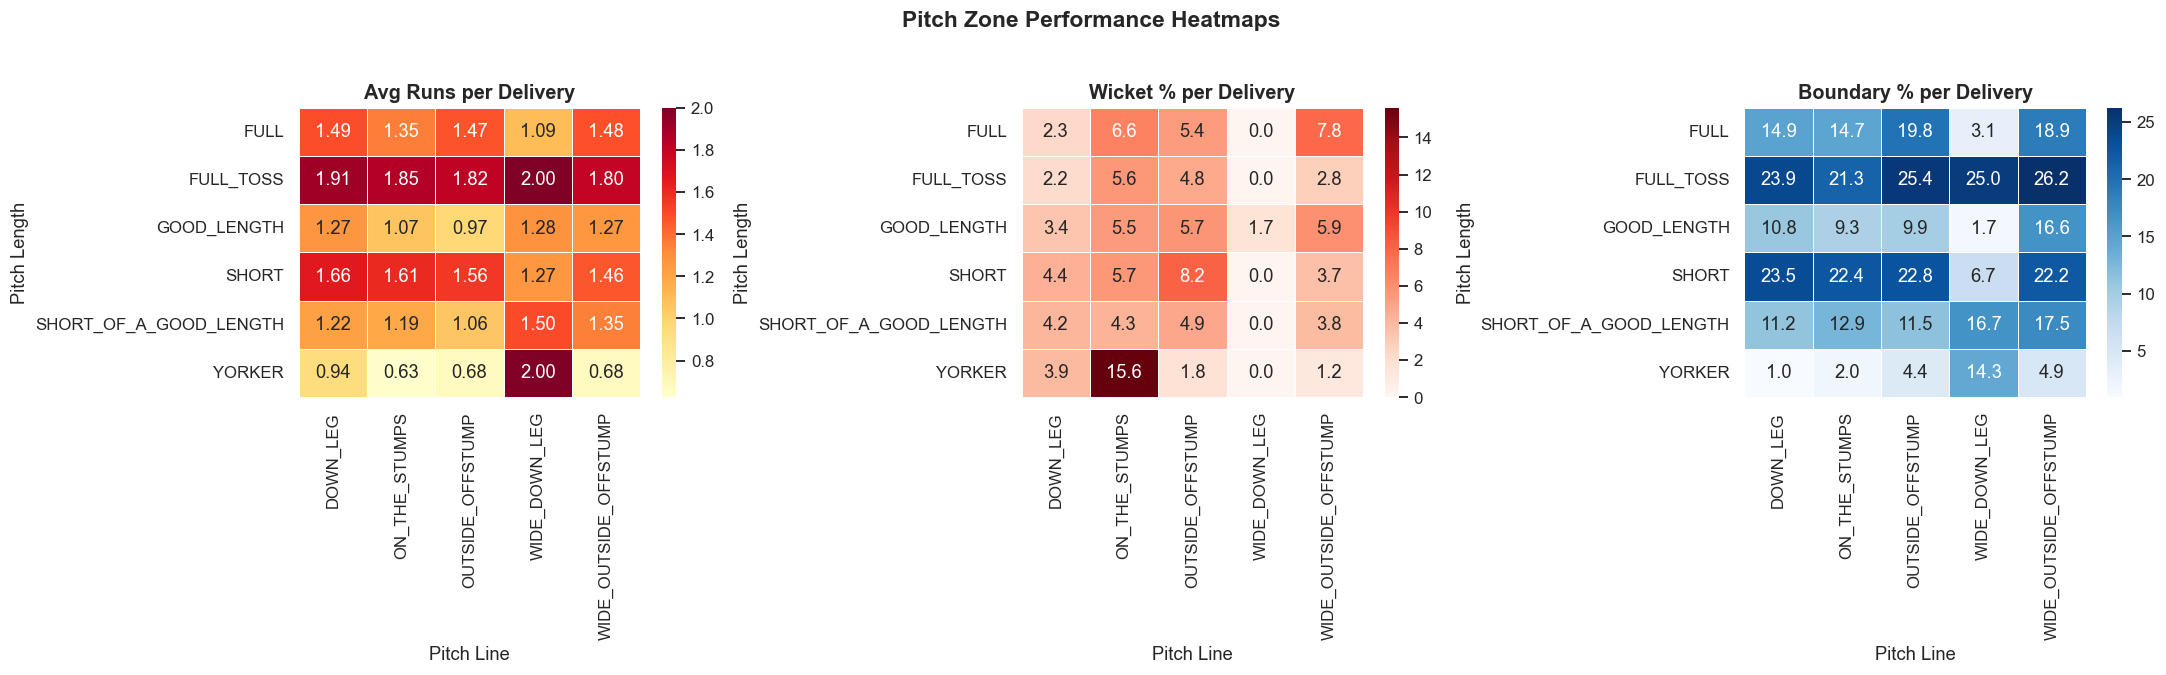

In [22]:
metrics = {'avg_run': 'run', 'wicket_pct': 'isWicket', 'boundary_pct': 'isBoundary'}
titles  = {'avg_run': 'Avg Runs', 'wicket_pct': 'Wicket %', 'boundary_pct': 'Boundary %'}

pivot_run  = df.pivot_table('run',        index='pitchLength', columns='pitchLine', aggfunc='mean')
pivot_wkt  = df.pivot_table('isWicket',   index='pitchLength', columns='pitchLine', aggfunc='mean') * 100
pivot_bdry = df.pivot_table('isBoundary', index='pitchLength', columns='pitchLine', aggfunc='mean') * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, pivot, title, fmt, cmap in zip(
    axes,
    [pivot_run, pivot_wkt, pivot_bdry],
    ['Avg Runs per Delivery', 'Wicket % per Delivery', 'Boundary % per Delivery'],
    ['.2f', '.1f', '.1f'],
    ['YlOrRd', 'Reds', 'Blues']
):
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Pitch Line')
    ax.set_ylabel('Pitch Length')

plt.suptitle('Pitch Zone Performance Heatmaps', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Shot Type Analysis

In [23]:
shot_stats = df.groupby('shotType').agg(
    count       = ('run', 'count'),
    avg_runs    = ('run', 'mean'),
    boundary_pct= ('isBoundary', 'mean'),
    wicket_pct  = ('isWicket', 'mean')
).reset_index().sort_values('avg_runs', ascending=False)

shot_stats['boundary_pct'] *= 100
shot_stats['wicket_pct']   *= 100

fig = make_subplots(rows=1, cols=2, subplot_titles=('Avg Runs by Shot Type', 'Boundary % by Shot Type'))

fig.add_trace(go.Bar(x=shot_stats['shotType'], y=shot_stats['avg_runs'].round(2),
                     marker_color='steelblue', name='Avg Runs'), row=1, col=1)
fig.add_trace(go.Bar(x=shot_stats['shotType'], y=shot_stats['boundary_pct'].round(1),
                     marker_color='tomato', name='Boundary %'), row=1, col=2)

fig.update_layout(title='Shot Type Effectiveness', height=480, showlegend=False)
fig.update_xaxes(tickangle=-45)
fig.show()

## 7. Bowler Style Effectiveness

In [24]:
bowler_style = df.groupby('Bowler_Bowling_Style').agg(
    deliveries  = ('run', 'count'),
    avg_runs    = ('run', 'mean'),
    wicket_pct  = ('isWicket', 'mean'),
    dot_pct     = ('isDotBall', 'mean'),
    boundary_pct= ('isBoundary', 'mean')
).reset_index()
# Filter styles with enough samples
bowler_style = bowler_style[bowler_style['deliveries'] >= 200].copy()
bowler_style['wicket_pct']   *= 100
bowler_style['dot_pct']      *= 100
bowler_style['boundary_pct'] *= 100

fig = px.scatter(
    bowler_style, x='dot_pct', y='wicket_pct',
    size='deliveries', color='avg_runs',
    hover_name='Bowler_Bowling_Style',
    color_continuous_scale='RdYlGn_r',
    title='Bowler Style: Dot Ball % vs Wicket % (bubble = deliveries, colour = avg runs)',
    labels={'dot_pct': 'Dot Ball %', 'wicket_pct': 'Wicket %'}
)
fig.show()

In [25]:
# Economy (avg runs) by bowling style — horizontal bar
bowler_style_sorted = bowler_style.sort_values('avg_runs')
fig = px.bar(bowler_style_sorted, y='Bowler_Bowling_Style', x='avg_runs',
             orientation='h', color='avg_runs',
             color_continuous_scale='RdYlGn_r',
             title='Avg Runs Conceded per Delivery by Bowling Style',
             text=bowler_style_sorted['avg_runs'].round(2))
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title='', xaxis_title='Avg Runs / Delivery', coloraxis_showscale=False)
fig.show()

## 8. Match Phase Analysis

In [26]:
phase_stats = df.groupby('match_phase').agg(
    avg_runs    = ('run', 'mean'),
    boundary_pct= ('isBoundary', 'mean'),
    wicket_pct  = ('isWicket', 'mean'),
    dot_pct     = ('isDotBall', 'mean')
).reset_index()
phase_stats[['boundary_pct','wicket_pct','dot_pct']] *= 100
phase_order = ['Powerplay', 'Middle', 'Death']
phase_stats = phase_stats.set_index('match_phase').reindex(phase_order).reset_index()

fig = make_subplots(rows=1, cols=4,
    subplot_titles=['Avg Runs/Ball', 'Boundary %', 'Wicket %', 'Dot Ball %'])

colors = ['#2ecc71', '#e67e22', '#e74c3c']
for i, (col, label) in enumerate([
    ('avg_runs',    'Avg Runs'),
    ('boundary_pct','Boundary %'),
    ('wicket_pct',  'Wicket %'),
    ('dot_pct',     'Dot Ball %')
], 1):
    fig.add_trace(go.Bar(
        x=phase_stats['match_phase'], y=phase_stats[col].round(2),
        marker_color=colors, text=phase_stats[col].round(2),
        textposition='outside', showlegend=False
    ), row=1, col=i)

fig.update_layout(title='Match Phase Comparison', height=420)
fig.show()

## 9. Over-by-Over Run Rate Curve

In [27]:
df['over_int'] = df['oversActual'].astype(int)
over_stats = df.groupby('over_int').agg(
    avg_runs    = ('run', 'mean'),
    boundary_pct= ('isBoundary', 'mean'),
    wicket_pct  = ('isWicket', 'mean')
).reset_index()
over_stats[['boundary_pct','wicket_pct']] *= 100

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Avg Runs per Over', 'Boundary & Wicket % per Over'])

fig.add_trace(go.Scatter(x=over_stats['over_int'], y=over_stats['avg_runs'],
                          mode='lines+markers', name='Avg Runs', line=dict(color='royalblue')), row=1, col=1)

fig.add_trace(go.Scatter(x=over_stats['over_int'], y=over_stats['boundary_pct'],
                          mode='lines', name='Boundary %', line=dict(color='tomato')), row=2, col=1)
fig.add_trace(go.Scatter(x=over_stats['over_int'], y=over_stats['wicket_pct'],
                          mode='lines', name='Wicket %', line=dict(color='green')), row=2, col=1)

# Phase shading
for fig_row in [1, 2]:
    fig.add_vrect(x0=1, x1=6,  fillcolor='lightgreen', opacity=0.15, layer='below', line_width=0, row=fig_row, col=1)
    fig.add_vrect(x0=7, x1=15, fillcolor='lightyellow', opacity=0.25, layer='below', line_width=0, row=fig_row, col=1)
    fig.add_vrect(x0=16, x1=20, fillcolor='lightsalmon', opacity=0.2, layer='below', line_width=0, row=fig_row, col=1)

fig.update_layout(title='Over-by-Over Trends  (green=Powerplay, yellow=Middle, red=Death)',
                  height=560, xaxis2_title='Over')
fig.show()

## 10. Time-of-Day Effects

In [28]:
tod = df.groupby('time_of_day').agg(
    avg_runs    = ('run', 'mean'),
    boundary_pct= ('isBoundary', 'mean'),
    wicket_pct  = ('isWicket', 'mean'),
    deliveries  = ('run', 'count')
).reset_index()
tod[['boundary_pct','wicket_pct']] *= 100

fig = make_subplots(rows=1, cols=3,
    subplot_titles=['Avg Runs / Delivery', 'Boundary %', 'Wicket %'])

for i, col in enumerate(['avg_runs', 'boundary_pct', 'wicket_pct'], 1):
    fig.add_trace(go.Bar(x=tod['time_of_day'], y=tod[col].round(2),
                         text=tod[col].round(2), textposition='outside',
                         marker_color=['#3498db','#e67e22','#9b59b6'],
                         showlegend=False), row=1, col=i)

fig.update_layout(title='Time-of-Day Effect on Match Outcomes', height=420)
fig.show()

## 11. Batting Style vs Outcomes

In [29]:
bat_style = df.groupby(['Batsman_Batting_Style', 'match_phase']).agg(
    avg_runs    = ('run', 'mean'),
    boundary_pct= ('isBoundary', 'mean')
).reset_index()
bat_style['boundary_pct'] *= 100

fig = make_subplots(rows=1, cols=2, subplot_titles=['Avg Runs', 'Boundary %'])
for i, col in enumerate(['avg_runs', 'boundary_pct'], 1):
    for style in bat_style['Batsman_Batting_Style'].unique():
        sub = bat_style[bat_style['Batsman_Batting_Style'] == style]
        sub = sub.set_index('match_phase').reindex(['Powerplay','Middle','Death']).reset_index()
        fig.add_trace(go.Bar(x=sub['match_phase'], y=sub[col].round(2),
                             name=style, legendgroup=style,
                             showlegend=(i == 1)), row=1, col=i)

fig.update_layout(title='RHB vs LHB — Phase-wise Performance', barmode='group', height=420)
fig.show()

## 12. Innings Comparison

In [30]:
innings = df.groupby(['inningNumber', 'match_phase']).agg(
    avg_runs    = ('run', 'mean'),
    wicket_pct  = ('isWicket', 'mean'),
    boundary_pct= ('isBoundary', 'mean')
).reset_index()
innings[['wicket_pct','boundary_pct']] *= 100
innings['Innings'] = innings['inningNumber'].map({1: '1st Innings', 2: '2nd Innings'})

fig = px.bar(innings, x='match_phase', y='avg_runs',
             color='Innings', barmode='group',
             category_orders={'match_phase': ['Powerplay','Middle','Death']},
             title='1st vs 2nd Innings — Avg Runs by Phase',
             color_discrete_sequence=['#3498db','#e74c3c'])
fig.show()

## 13. Wicket Probability by Pitch Zone

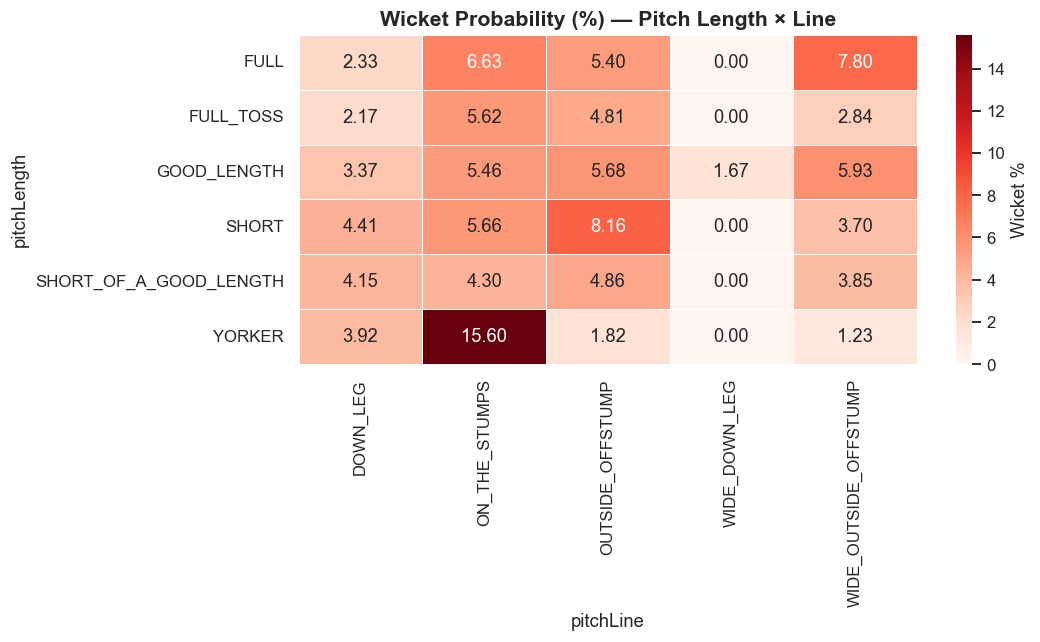

In [31]:
pivot_wkt = df.pivot_table('isWicket', index='pitchLength', columns='pitchLine', aggfunc='mean') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_wkt, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': 'Wicket %'})
plt.title('Wicket Probability (%) — Pitch Length × Line', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Shot Selection by Pitch Length

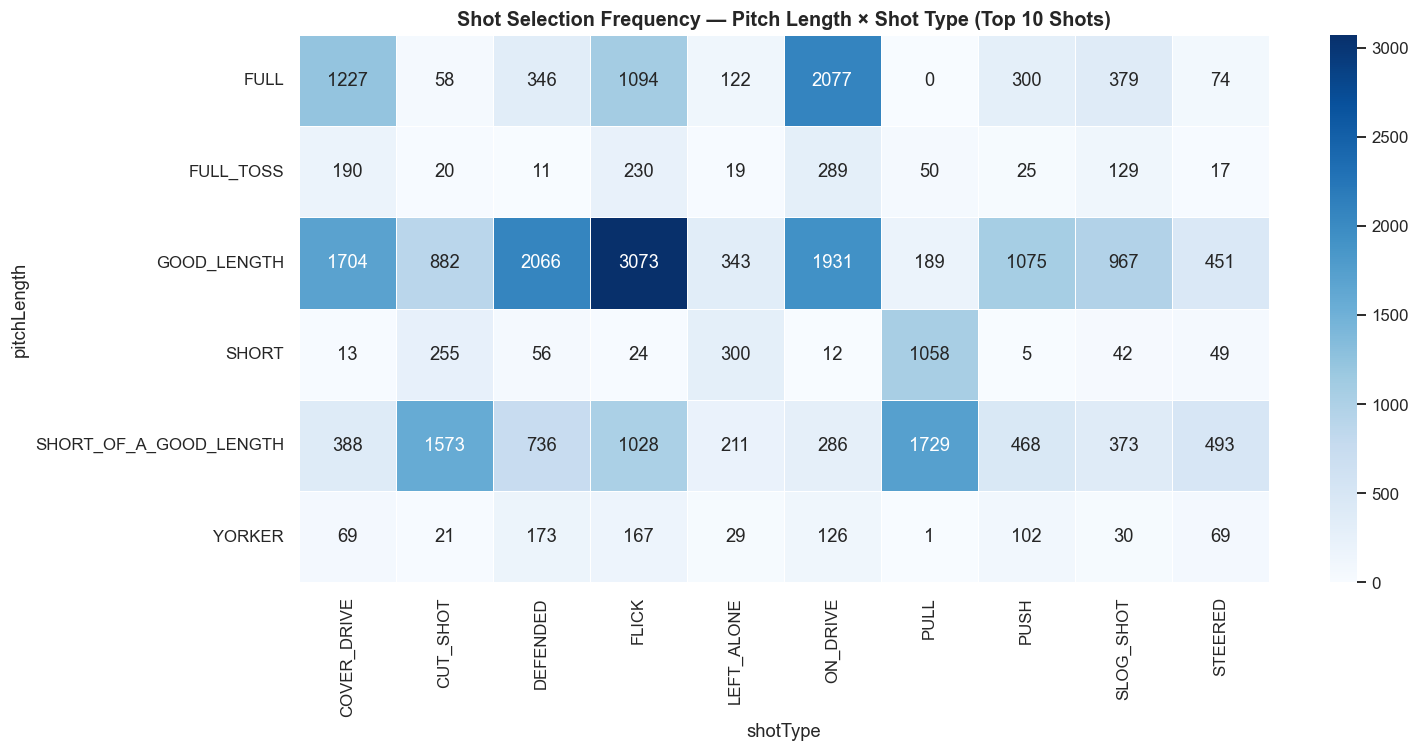

In [32]:
shot_len  = df.groupby(["pitchLength", "shotType"]).size().reset_index(name="count")
# Top 10 shots only for readability
top_shots = df["shotType"].value_counts().head(10).index
shot_len  = shot_len[shot_len["shotType"].isin(top_shots)]

pivot_shot = (
    shot_len.pivot_table("count", index="pitchLength", columns="shotType", fill_value=0)
    .astype(int)   # pivot_table returns float by default; cast to int for fmt="d"
)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_shot, annot=True, fmt="d", cmap="Blues", linewidths=0.4)
plt.title("Shot Selection Frequency — Pitch Length × Shot Type (Top 10 Shots)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 15. Run Distribution

In [33]:
run_dist = df['run'].value_counts().sort_index().reset_index()
run_dist.columns = ['runs', 'count']

fig = px.bar(run_dist, x='runs', y='count',
             text='count', color='runs',
             color_continuous_scale='Blues',
             title='Run Distribution per Delivery',
             labels={'runs': 'Runs Scored', 'count': 'Number of Deliveries'})
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

print('Summary stats for runs per delivery:')
print(df['run'].describe().round(3))

Summary stats for runs per delivery:
count    33029.000
mean         1.189
std          1.510
min          0.000
25%          0.000
50%          1.000
75%          1.000
max          7.000
Name: run, dtype: float64
